In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-07 13:13:07.683730


In [2]:
import csv
import os
import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

## Functions

In [4]:
def kde_grid_plot(
    adata, genes, palette, alpha, linewidth,
    group_col="reporter_status", ncols=5, subplot_size=(2.5, 2.5), gene_fontsize=14
):
    sns.set_theme(style="ticks")
    df = adata.to_df()[genes]
    nrows = math.ceil(len(genes) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols, 
        figsize=(ncols * subplot_size[0], nrows * subplot_size[1])
    )
    axes = np.atleast_1d(axes).flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        for cat, color in palette.items():
            mask = adata.obs[group_col] == cat
            if mask.any():
                sns.kdeplot(
                    df.loc[mask, gene], ax=ax, fill=True, color=color,
                    alpha=alpha.get(cat, 0.4) if isinstance(alpha, dict) else alpha,
                    linewidth=linewidth.get(cat, 2) if isinstance(linewidth, dict) else linewidth,
                    label=str(cat)
                )

        ax.set_title(f"$\\it{{{gene}}}$", fontsize=gene_fontsize)
        ax.set_yticks([])
        ax.set_ylabel("Density" if i % ncols == 0 else "", fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()
    return fig

In [5]:
palette = {
    "EGFP_Seq1_hi": "limegreen", 
    "dTomato_Seq2_hi": "magenta", 
    "EGFP_dTomato_dual_hi": "blue",
    "Negative": "black"
}

# Prepare data

In [6]:
input_dir = "/home/workspace/private/geo_organized"
adata = sc.read_h5ad(os.path.join(input_dir, 'adata_processed.h5ad'))
adata


AnnData object with n_obs × n_vars = 147036 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'slide_id', 'n_genes_by_counts', 'cell_type', 'cell_class', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status', 'innervation_pattern', 'neuron_filter'
    uns: 'cell_type_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [8]:
adata = adata[adata.obs['neuron_filter'] == 'Pass'].copy()
adata

AnnData object with n_obs × n_vars = 22411 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'slide_id', 'n_genes_by_counts', 'cell_type', 'cell_class', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status', 'innervation_pattern', 'neuron_filter'
    uns: 'cell_type_colors', 'log1p'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'

In [9]:
groups = ['CGRP-Gamma 1', 'CGRP-Gamma 2']
bdata = adata[adata.obs['cell_type'].isin(groups)].copy()
bdata

AnnData object with n_obs × n_vars = 6186 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'slide_id', 'n_genes_by_counts', 'cell_type', 'cell_class', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status', 'innervation_pattern', 'neuron_filter'
    uns: 'cell_type_colors', 'log1p'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'

## Calculate dendrogram from latent rep

In [26]:
sc.tl.dendrogram(adata, groupby = 'cell_type', use_rep = 'X_scVI')
sc.tl.dendrogram(bdata, groupby = 'cell_type', use_rep = 'X_scVI')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


## Dotplots

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

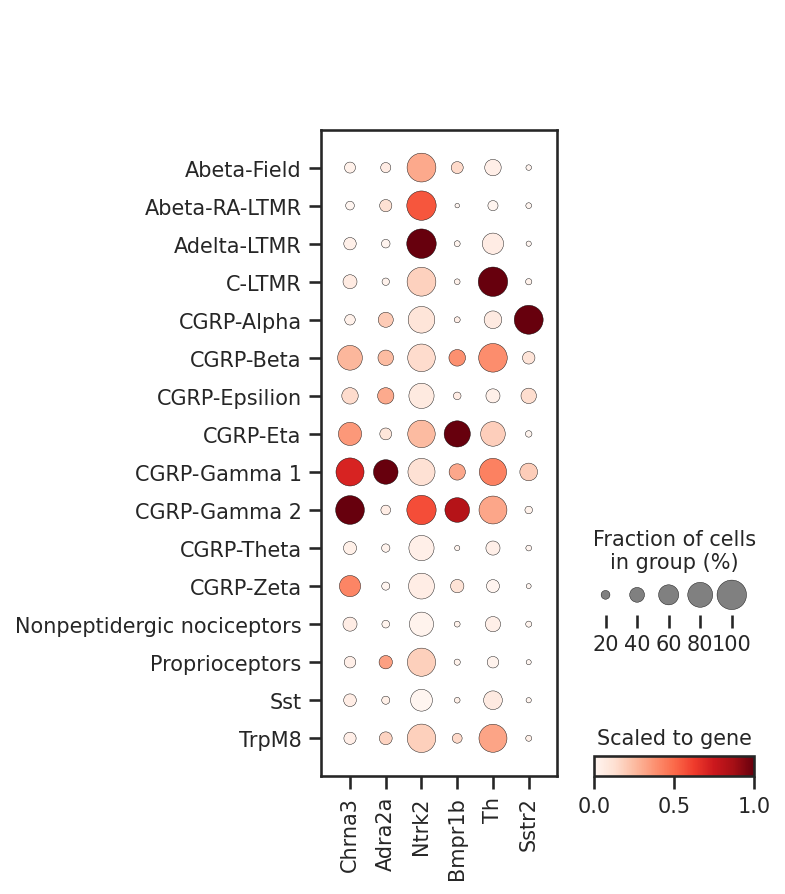

In [31]:
genes = ['Chrna3', 'Adra2a', 'Ntrk2', 'Bmpr1b', 'Th', 'Sstr2']

# Bubble plots of all groups, and of just CGRP-Gamma 1 subsets

sc.pl.dotplot(adata, var_names = genes, groupby = 'cell_type', standard_scale = 'var', colorbar_title = 'Scaled to gene')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

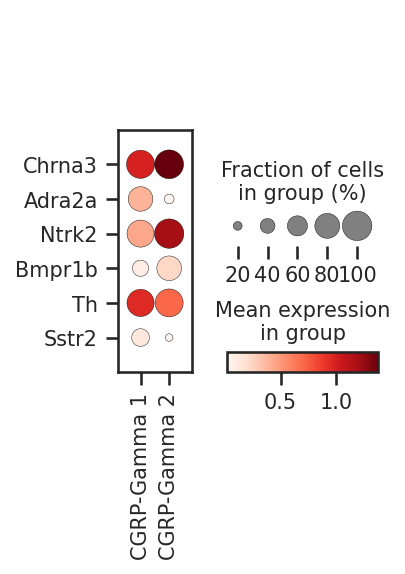

In [35]:
sc.pl.dotplot(bdata, var_names = genes, groupby = 'cell_type', swap_axes = True)

## Histograms

In [12]:
print(adata.obs.dtypes)

cell_id                   object
x_centroid               float64
y_centroid               float64
total_counts             float32
cell_area                float64
nucleus_area             float64
nucleus_count              int64
segmentation_method     category
sample_id               category
slide_id                category
n_genes_by_counts          int32
cell_type               category
cell_class              category
EGFP_Seq1_hi            category
dTomato_Seq2_hi         category
EGFP_dTomato_dual_hi    category
reporter_status         category
innervation_pattern     category
neuron_filter           category
dtype: object


In [13]:
adata.obs.reporter_status.value_counts()

reporter_status
Negative                22264
dTomato_Seq2_hi            89
EGFP_Seq1_hi               39
EGFP_dTomato_dual_hi       19
Name: count, dtype: int64

In [14]:
genes = ['Calca', 'Calcb', 'Chrna3', 'Adra2a', 'Trpv1', 'Ntrk1', 'Ntrk2', 'Ntrk3', 'Piezo2', 'Bmpr1b', 'Th', 'Sstr2']

/tmp/ipykernel_2836/2264963461.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


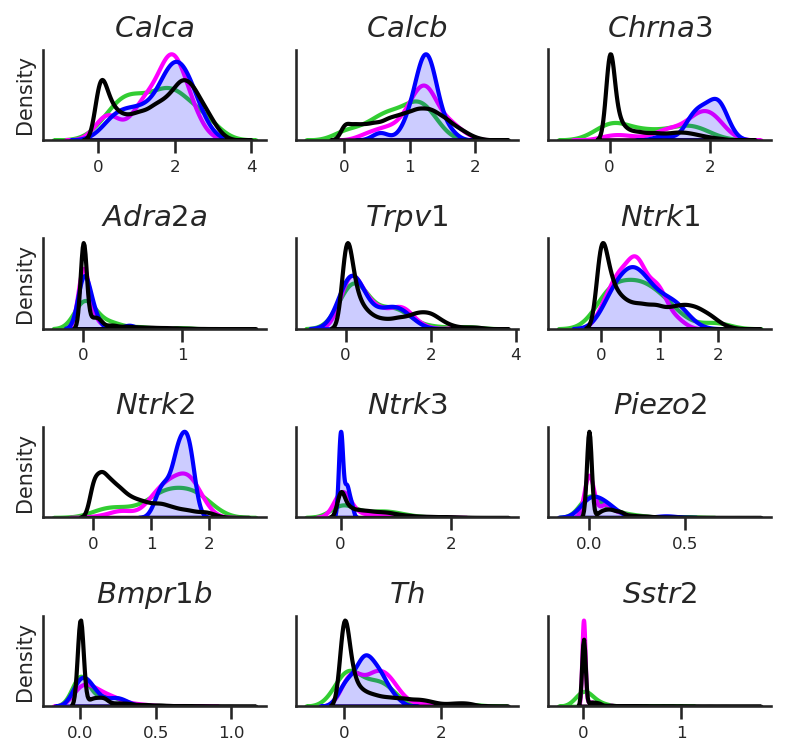

In [15]:
fig = kde_grid_plot(
    adata=adata,
    genes=genes,
    group_col="reporter_status",
    ncols=3,
    subplot_size=(1.8, 1.3),
    palette= palette,
    alpha={
        "EGFP_Seq1_hi": 0, 
        "dTomato_Seq2_hi": 0, 
        "EGFP_dTomato_dual_hi": 0.2,
        "Negative": 0
    },
    # Set custom line thickness: dual-positive is bold (3.5), others are thinner (2)
    linewidth={
        "EGFP_Seq1_hi": 2,  
        "dTomato_Seq2_hi": 2, 
        "EGFP_dTomato_dual_hi": 2
    }
)

plt.show()

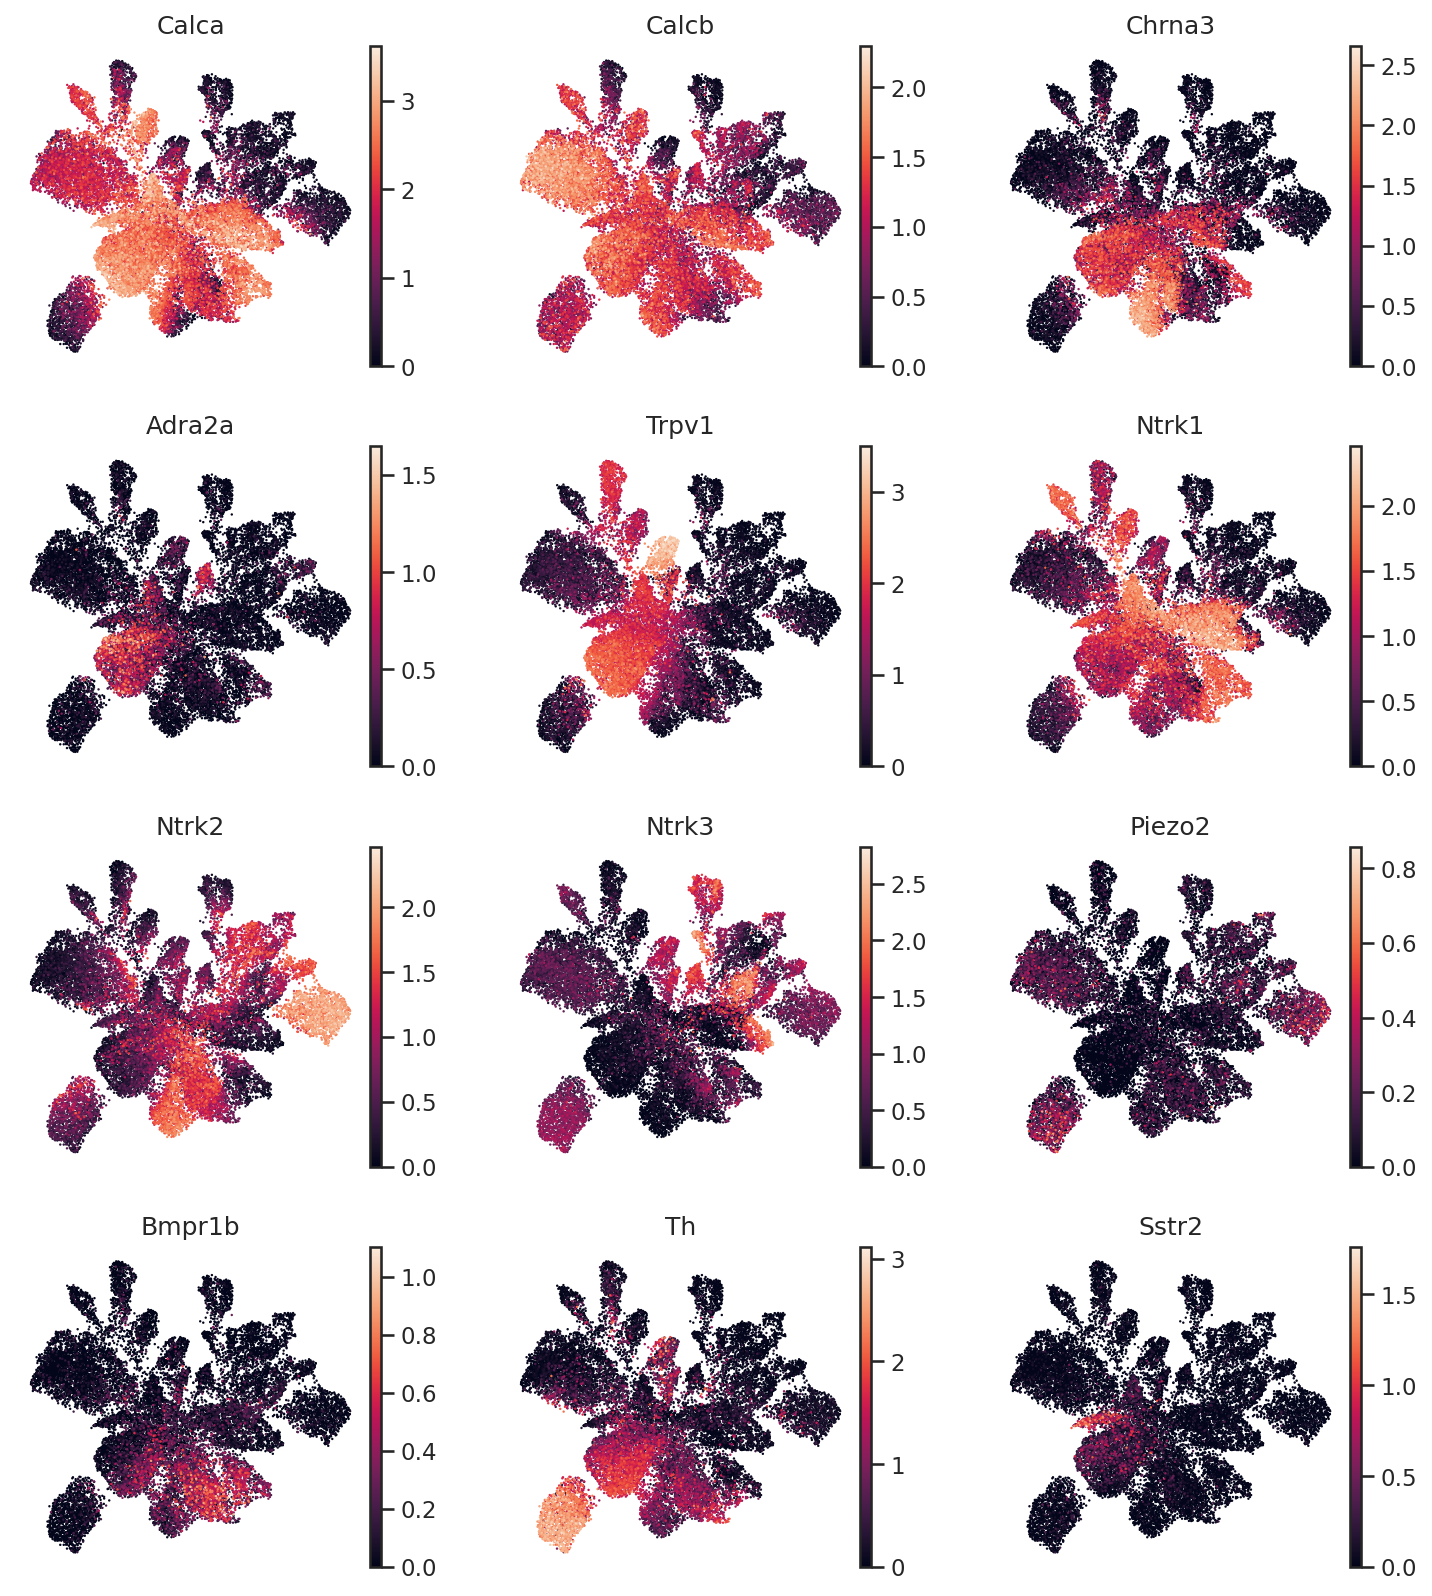

In [16]:
sc.pl.umap(adata, color = genes, frameon = False, ncols = 3)

## Heatmaps

In [17]:
genes = ['Calca', 'Calcb', 'Chrna3', 'Adra2a', 'Trpv1', 'Ntrk1', 'Ntrk2', 'Ntrk3', 'Piezo2', 'Bmpr1b', 'Th', 'Sstr2']

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


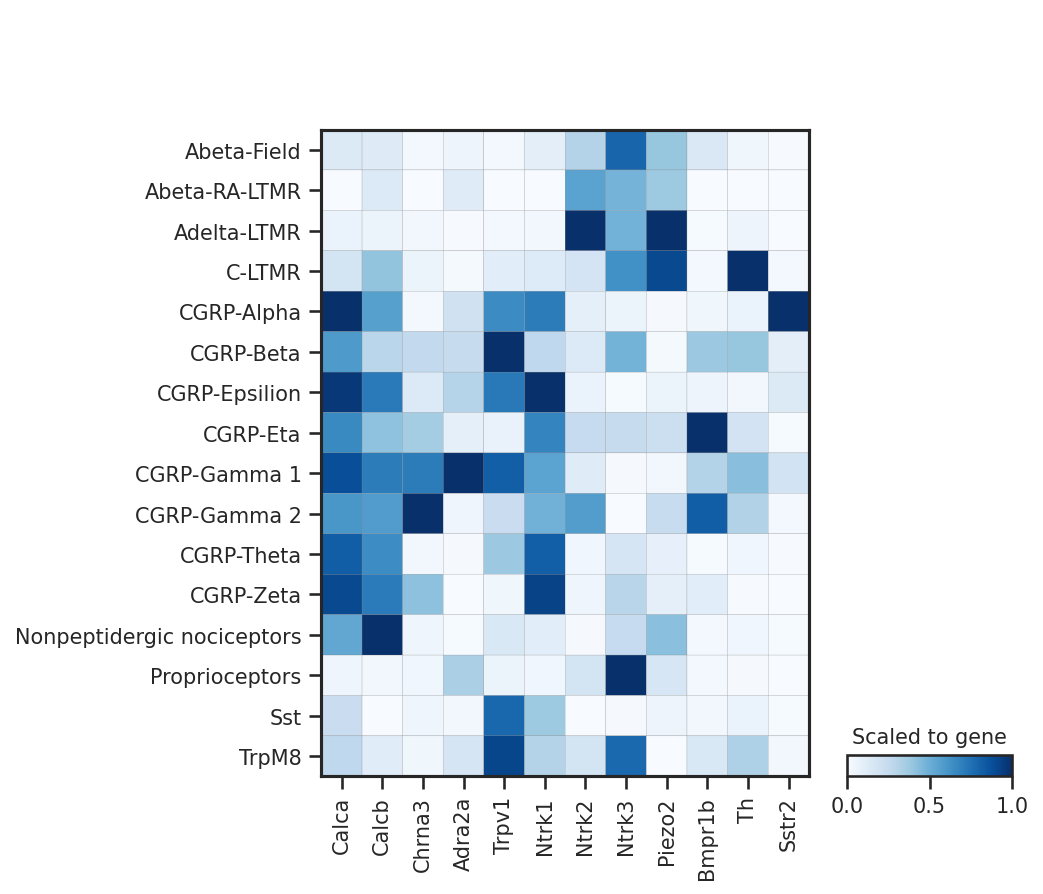

In [22]:
sc.pl.matrixplot(adata, 
                     var_names = genes, 
                     groupby = 'cell_type',
                     standard_scale = 'var', 
                     colorbar_title = 'Scaled to gene', 
                     cmap = 'Blues')

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_stacked_violin.py:324: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _color_df = _matrix.groupby(level=0).median()
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_stacked_violin.py:405: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(_matrix.stack(dropna=False))
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed

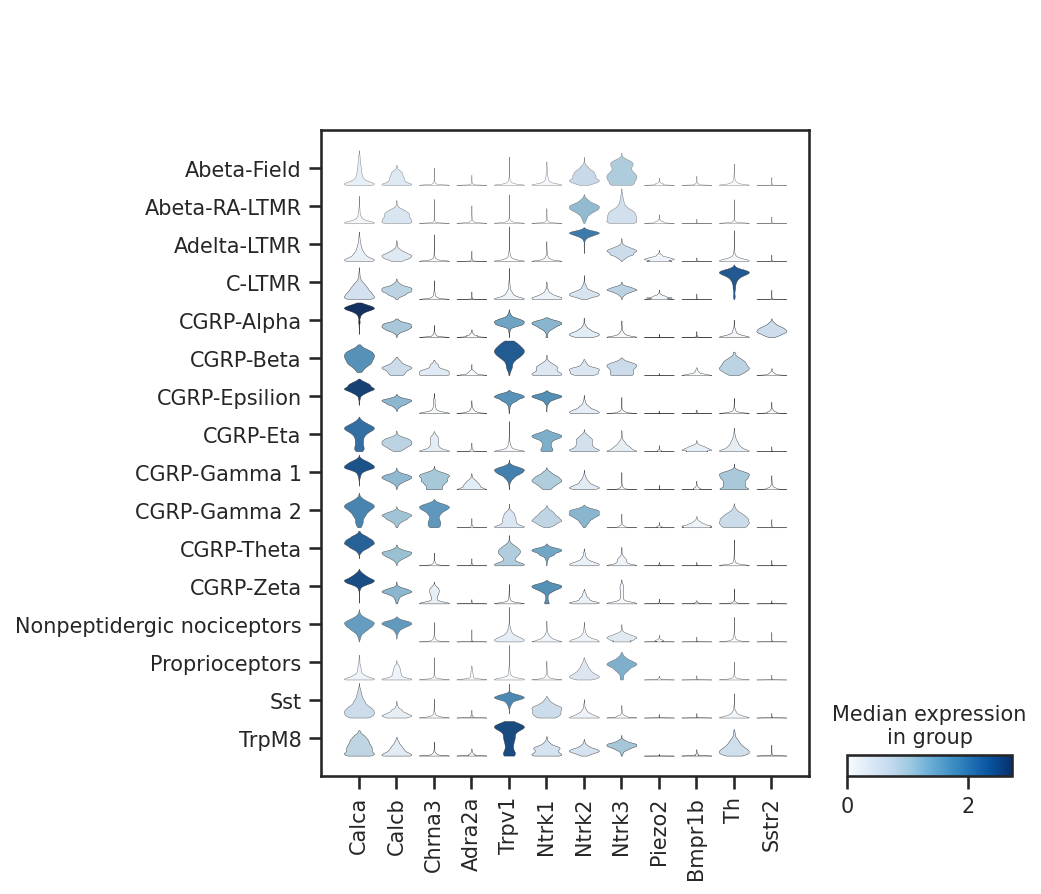

In [23]:
sc.pl.stacked_violin(adata, 
                     var_names = genes, 
                     groupby = 'cell_type',
                     cmap = 'Blues')